#**Overview of the Proposed WCCAN Framework**

<div style="
    width: 92%;
    max-width: 1200px;
    margin: 0 auto;
">

<p style="
    text-align: left;
    line-height: 1.65;
    margin: 0;
    padding: 0 20px;
    font-size: 16px;
    letter-spacing: normal;
    word-spacing: normal;
">
This Jupyter notebook presents the <strong>Windowed Cross-Contrast Attention Network (WCCAN)</strong>, a general and computationally efficient reference-guided framework for multi-contrast magnetic resonance image super-resolution (MCMSR). The framework is designed to support different contrast pairings rather than being restricted to a fixed clinical protocol. WCCAN integrates three complementary components to address high-frequency (HF) information recovery, computational efficiency, and cross-contrast feature consistency. The <strong>Wavelet-Guided High-Frequency Prior Modeling Block (WHPMB)</strong> explicitly extracts and enhances directional HF information from the HR reference contrast through directional decomposition and bounded nonlinear enhancement. The <strong>Triple Cross-Contrast Fusion Module (TCCFM)</strong> incorporates the proposed <strong>Windowed Cross-Contrast Attention Module (WCCAM)</strong> to efficiently transfer complementary information between the reference and target contrasts while reducing the computational cost associated with global attention. Finally, the <strong>Consistent Feature Fusion Module (CFFM)</strong> with <strong>Selective Spatial Adaptive Modulation (SSAM)</strong> facilitates the integration of cross-contrast features by reducing feature discrepancies between the target and reference representations.
</p>

</div>

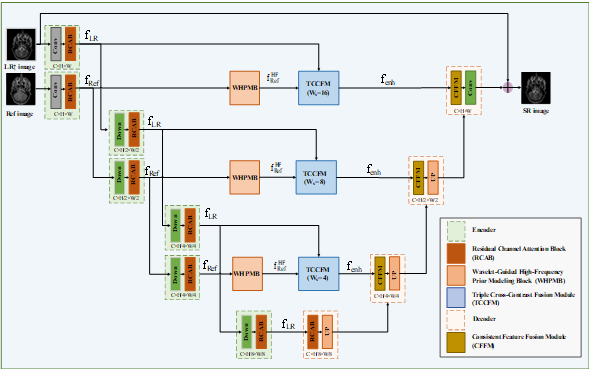

# **Proposed WCCAN Framework Architecture**

# **Encoder**

 **Required Libraries**

In [ ]:
import os, sys, math, functools
import torch, torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from thop import profile
from thop import clever_format
from torch.utils.data import Dataset
import numpy as np

In [ ]:
class ECA(nn.Module):
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1,1, kernel_size=k_size,padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv( y.squeeze(-1).transpose(-1, -2))
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)
class RCAB(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, 1)
        )
        self.attn = ECA(channels)
    def forward(self, x):
        res = x
        x = self.body(x)
        x = self.attn(x)
        return x + res
def make_layer(block, n_layers):
    layers = []
    for _ in range(n_layers):
        layers.append(block())
    return nn.Sequential(*layers)
class Encoder(nn.Module):
    def __init__(self, input_channels, channels, n_blks=[1,1,1], act='relu'):
        super().__init__()
        block = functools.partial(RCAB, channels=channels)
        self.conv_L1 = nn.Conv2d(input_channels, channels, 3,1,1,bias=True)
        self.blk_L1  = make_layer(block, n_blks[0])
        self.conv_L2 = nn.Conv2d(channels, channels, 3,2,1,bias=True)
        self.blk_L2  = make_layer(block, n_blks[1])
        self.conv_L3 = nn.Conv2d(channels, channels, 3,2,1,bias=True)
        self.blk_L3  = make_layer(block, n_blks[2])
        self.act = nn.ReLU(inplace=True) if act=='relu' else nn.LeakyReLU(0.1,inplace=True)
    def forward(self, x):
        f1 = self.blk_L1(self.act(self.conv_L1(x)))
        f2 = self.blk_L2(self.act(self.conv_L2(f1)))
        f3 = self.blk_L3(self.act(self.conv_L3(f2)))
        return [f1, f2, f3]

# **Wavelet-Guided High-Frequency Prior Modeling Block (WHPMB)**

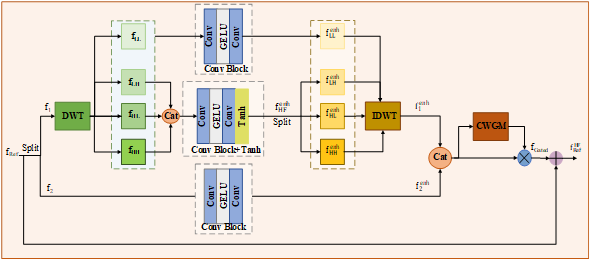

In [ ]:
class HaarDWT(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        sqrt2 = 1.0 / math.sqrt(2)
        l = torch.tensor([sqrt2, sqrt2], dtype=torch.float32)
        h = torch.tensor([sqrt2, -sqrt2], dtype=torch.float32)
        ll = l[:, None] * l[None, :]
        lh = l[:, None] * h[None, :]
        hl = h[:, None] * l[None, :]
        hh = h[:, None] * h[None, :]
        weight = torch.stack([ll, lh, hl, hh], dim=0)
        weight = weight.unsqueeze(1).repeat(channels, 1, 1, 1, 1)
        self.register_parameter("weight", nn.Parameter(weight))
        self.groups = channels
    def forward(self, x):
        B, C, H, W = x.shape
        y = F.conv2d(x, self.weight.view(4 * C, 1, 2, 2),
                     stride=2, groups=self.groups)
        y = y.view(B, C, 4, H // 2, W // 2)
        return [y[:, :, i] for i in range(4)]

class HaarIDWT(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.dwt = HaarDWT(channels)

    def forward(self, LL, LH, HL, HH):
        B, C, H, W = LL.shape
        stacked = torch.stack([LL, LH, HL, HH], dim=2)
        y = stacked.view(B, 4 * C, H, W)
        out = F.conv_transpose2d(y,
                                 self.dwt.weight.view(4 * C, 1, 2, 2),
                                 stride=2,
                                 groups=self.dwt.groups)
        return out

class WHPMB(nn.Module):
    def __init__(self, channels, reduction=6):
        super().__init__()
        half = channels // 2
        self.dwt = HaarDWT(half)
        self.idwt = HaarIDWT(half)

        self.Conv_Block = nn.Sequential(
            nn.Conv2d(half, half, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(half, half, 3, padding=1))

        self.Conv_BlockTanh = nn.Sequential(
            nn.Conv2d(3 * half, half * 2, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(half * 2, 3 * half, 3, padding=1),
            nn.Tanh()  )

        self.CWGM = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        B, C, H, W = x.shape
        x1, x2 = torch.chunk(x, 2, dim=1)
        # HF extraction
        LL, LH, HL, HH = self.dwt(x1)
        # Enhanced low-frequency processing
        LL_enhanced = self.Conv_Block(LL)
        # Process details
        details = torch.cat([LH, HL, HH], dim=1)
        details_enhanced = self.Conv_BlockTanh(details)
        LH_enhanced, HL_enhanced, HH_enhanced = torch.chunk(details_enhanced, 3, dim=1)
        # Reconstruct enhanced features
        x1_enhanced = self.idwt(LL_enhanced, LH_enhanced, HL_enhanced, HH_enhanced)
        x2_enhanced = self.Conv_Block(x2)
        # Adaptive fusion
        out = torch.cat([x1_enhanced, x2_enhanced], dim=1)
        gate = self.CWGM(out)
        out = out * gate + x
        return out


# **Windowed Cross-Contrast Attention Module (WCCAM)**

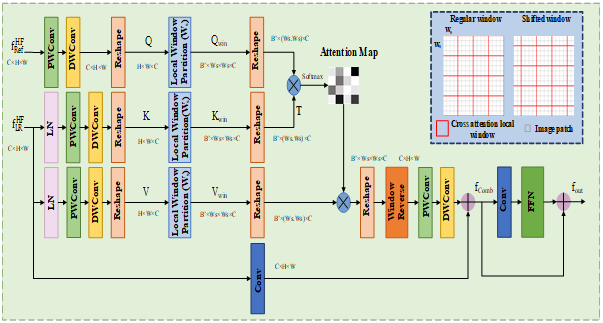

In [ ]:
def window_partition(x, window_size):
    B, C, H, W = x.shape
    x = x.view(B, C, H // window_size, window_size, W // window_size, window_size)
    windows = x.permute(0, 2, 4, 1, 3, 5).contiguous().view(-1, C, window_size, window_size)
    return windows

def window_reverse(windows, window_size, H, W):
    B_num = int(windows.shape[0] / ((H // window_size) * (W // window_size)))
    x = windows.view(B_num, H // window_size, W // window_size, -1, window_size, window_size)
    x = x.permute(0, 3, 1, 4, 2, 5).contiguous().view(B_num, -1, H, W)
    return x

class WindowedCrossContrastAttentionModule(nn.Module):
    def __init__(self, channels, window_size=16, shift_size=0):
        super().__init__()

        self.window_size = window_size
        self.shift_size = shift_size  # 0 for regular, window_size//2 for shifted

        self.pconv_q = nn.Conv2d(channels, channels, 1)
        self.dconv_q = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.ln_k = nn.LayerNorm(channels)
        self.pconv_k = nn.Conv2d(channels, channels, 1)
        self.dconv_k = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.pconv_v = nn.Conv2d(channels, channels, 1)
        self.dconv_v = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.conv_r = nn.Conv2d(channels, channels, 3, padding=1)
        self.ffn = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 1),
            nn.GELU(),
            nn.Conv2d(channels * 4, channels, 1)
        )
        self.pconv= nn.Conv2d(channels, channels, 1)
        self.dconv= nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
    def forward(self, f_q, f_global):

        B, C, H_orig, W_orig = f_global.shape

        ws = self.window_size
        ss = self.shift_size

        # Pad if needed for windowing
        pad_h = (ws - H_orig % ws) % ws
        pad_w = (ws - W_orig % ws) % ws
        if pad_h > 0 or pad_w > 0:
            f_q_padded = F.pad(f_q, (0, pad_w, 0, pad_h))
            f_global_padded = F.pad(f_global, (0, pad_w, 0, pad_h))
        else:
            f_q_padded = f_q
            f_global_padded = f_global
        B, C, H, W = f_global_padded.shape

        # Cyclic shift if shifted
        if ss > 0:
            f_q_padded = torch.roll(f_q_padded, shifts=(-ss, -ss), dims=(2, 3))
            f_global_padded = torch.roll(f_global_padded, shifts=(-ss, -ss), dims=(2, 3))
        # Q
        q = self.dconv_q(self.pconv_q(f_q_padded))
        q = q.permute(0, 2, 3, 1) # B H W C
        # K
        fg_ln = self.ln_k(f_global_padded.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        k = self.dconv_k(self.pconv_k(fg_ln))
        k = k.permute(0, 2, 3, 1) # B H W C
        # V
        v = self.dconv_v(self.pconv_v(fg_ln))
        v = v.permute(0, 2, 3, 1) # B H W C

        # Window partition (B' C ws ws) where B' = B * (H/ws) * (W/ws)
        q_win = window_partition(q.permute(0, 3, 1, 2), ws)  # Permute to B C H W for partition
        k_win = window_partition(k.permute(0, 3, 1, 2), ws)
        v_win = window_partition(v.permute(0, 3, 1, 2), ws)

        # Attention (B' ws*ws C)
        q_win = q_win.view(-1, ws * ws, C)
        k_win = k_win.view(-1, ws * ws, C)
        v_win = v_win.view(-1, ws * ws, C)
        attn = (q_win @ k_win.transpose(-2, -1)) * (1.0 / math.sqrt(C))
        attn = attn.softmax(dim=-1)
        out = attn @ v_win # (-1, ws*ws, C)
        out = out.view(-1, C, ws, ws)

        # Reverse windows
        out = window_reverse(out, ws, H, W)

        # Roll back if shifted
        if ss > 0:
            out = torch.roll(out, shifts=(ss, ss), dims=(2, 3))
        # Unpad if needed
        out = out[:, :, :H_orig, :W_orig]

        out = self.dconv(self.pconv_q(out))
        out1 = self.dconv(f_global)
        comb = out1 + out
        out = self.dconv(comb)
        out = self.ffn(out)
        out = out + comb
        return out


# **Decoupled spatial-channel inverted bottleneck (DSCIB)**

In [ ]:
class DSCIB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.dwconv = nn.Conv2d(channels, channels, 7, padding=3, groups=channels)
        self.pwconv1 = nn.Conv2d(channels, channels * 4, 1)
        self.pwconv2 = nn.Conv2d(channels * 4, channels, 1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.bn2 = nn.BatchNorm2d(channels * 4)
        self.act = nn.GELU()
    def forward(self, x):
        res = x
        x = self.bn1(self.dwconv(x))
        x = self.act(x)
        x = self.bn2(self.pwconv1(x))
        x = self.act(x)
        x = self.pwconv2(x)
        return x + res

# **Triple Cross-Contrast Fusion Module (TCCFM)**

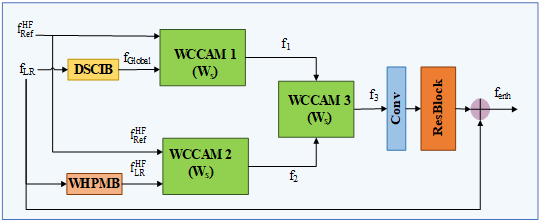

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, stride=1, padding=1, dilation=1, act='relu'):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size, stride, padding, dilation)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size, stride, padding, dilation)
        self.act = nn.ReLU(inplace=True) if act == 'relu' else nn.LeakyReLU(0.1, inplace=True)
    def forward(self, x):
        return self.conv2(self.act(self.conv1(x))) + x

class TripleCrossContrastFusionModule(nn.Module):
    def __init__(self, channels,window_size):
        super().__init__()
        self.DSCIB  = DSCIB(channels)
        self.WHPMB    = WHPMB(channels)
        shift_size = window_size // 2  # For shifted mode
        self.WCCAM1 = WindowedCrossContrastAttentionModule(channels, window_size, shift_size=0)  # Regular
        self.WCCAM2 = WindowedCrossContrastAttentionModule(channels, window_size, shift_size=shift_size)  # Shifted
        self.WCCAM3 = WindowedCrossContrastAttentionModule(channels, window_size, shift_size=0)  # Regular
        self.conv  = nn.Conv2d(channels, channels, 3, padding=1)
        self.Res= ResidualBlock(channels)
    def forward(self, f_lr, f_ref):
        f_ref_enh   = self.WHPMB(f_ref)
        f_lr_enh  = self.WHPMB(f_lr)
        f_global  = self.DSCIB(f_lr)
        f1 = self.WCCAM1(f_ref_enh, f_global)
        f2 = self.WCCAM2(f_lr_enh, f_ref_enh)
        f3 = self.WCCAM3(f1, f2)
        out = self.conv(f3)
        out=  self.Res(out)
        out = out + f_lr
        return out

# **Consistent Feature Fusion Module (CFFM) and Selective Spatial Adaptation Module (SSAM)**

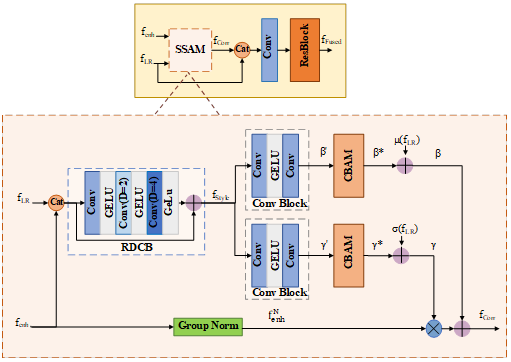

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding,bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x
class SSAM(nn.Module):
    def __init__(self, channels, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.norm = nn.GroupNorm(8, channels, affine=False)

        self.RDCB = nn.Sequential(
            nn.Conv2d(channels*2, channels*2, 3, 1, 1),
            nn.GELU(),
            nn.Conv2d(channels*2, channels*2, 3, 1, 2, dilation=2),
            nn.GELU(),
            nn.Conv2d(channels*2, channels, 3, 1, 4, dilation=4),
            nn.GELU(),
        )

        self.Conv_Block_g = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1))
        self.Conv_Block_b = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1))
        self.cbam_gamma = CBAM(channels)
        self.cbam_beta = CBAM(channels)

        # Zero-init affine
        nn.init.zeros_(self.Conv_Block_g[0].weight)
        nn.init.zeros_(self.Conv_Block_g[0].bias)
        nn.init.zeros_(self.Conv_Block_g[2].weight)
        nn.init.zeros_(self.Conv_Block_g[2].bias)
        nn.init.zeros_(self.Conv_Block_b[0].weight)
        nn.init.zeros_(self.Conv_Block_b[0].bias)
        nn.init.zeros_(self.Conv_Block_b[2].weight)
        nn.init.zeros_(self.Conv_Block_b[2].bias)

    def forward(self, lr, enh):
        enh_normed = self.norm(enh)
        style = self.RDCB(torch.cat([lr, enh], dim=1))
        gamma = self.Conv_Block_g(style)
        beta = self.Conv_Block_b(style)
        gamma1 = self.cbam_gamma(gamma)
        beta1= self.cbam_beta(beta)
        lr_std = lr.flatten(2).std(dim=2, keepdim=True).unsqueeze(-1)
        lr_mean = lr.flatten(2).mean(dim=2, keepdim=True).unsqueeze(-1)
        gamma = gamma1 + lr_std
        beta = beta1 + lr_mean
        return enh_normed * gamma + beta


# **Decoder**

In [ ]:
class Decoder(nn.Module):
    def __init__(self, channels, out_chl, n_blks=[1,1,1,1,1,1]):
        super().__init__()
        block = functools.partial(ResidualBlock, channels=channels)
        self.conv_L3 = nn.Conv2d(channels, channels, 3,2,1,bias=True)
        self.blk_L3 = make_layer(block, n_blks[0])
        self.conv_L2 = nn.Conv2d(channels, channels, 3,1,1,bias=True)
        self.blk_L2 = make_layer(block, n_blks[1])
        self.conv_L1 = nn.Conv2d(channels*2, channels, 3,1,1,bias=True)
        self.blk_L1 = make_layer(block, n_blks[2])
        self.merge_warp_x1 = nn.Conv2d(channels*2, channels, 3,1,1,bias=True)
        self.blk_x1 = make_layer(block, n_blks[3])
        self.merge_warp_x2 = nn.Conv2d(channels*2, channels, 3,1,1,bias=True)
        self.blk_x2 = make_layer(block, n_blks[4])
        self.merge_warp_x4 = nn.Conv2d(channels*2, channels, 3,1,1,bias=True)
        self.blk_x4 = make_layer(block, n_blks[5])
        self.conv_out = nn.Conv2d(64, out_chl, 3,1,1,bias=True)
        self.act = nn.ReLU(inplace=True)
        self.SSAM = SSAM(channels, use_residual=True)
    def forward(self, lr_l, warp_ref_l):
        fea_L3 = self.act(self.conv_L3(lr_l[2]))
        fea_L3 = self.blk_L3(fea_L3)
        fea_L2 = self.act(self.conv_L2(fea_L3))
        fea_L2 = self.blk_L2(fea_L2)
        fea_L2_up = F.interpolate(fea_L2, scale_factor=2, mode='bilinear', align_corners=False)
        fea_L1 = self.act(self.conv_L1(torch.cat([fea_L2_up, lr_l[2]], dim=1)))
        fea_L1 = self.blk_L1(fea_L1)
        warp_ref_x1 = self.SSAM(fea_L1, warp_ref_l[2])
        fea_x1 = self.act(self.merge_warp_x1(torch.cat([warp_ref_x1, fea_L1], dim=1)))
        fea_x1 = self.blk_x1(fea_x1)
        fea_x1_up = F.interpolate(fea_x1, scale_factor=2, mode='bilinear', align_corners=False)
        warp_ref_x2 = self.SSAM(fea_x1_up, warp_ref_l[1])
        fea_x2 = self.act(self.merge_warp_x2(torch.cat([warp_ref_x2, fea_x1_up], dim=1)))
        fea_x2 = self.blk_x2(fea_x2)
        fea_x2_up = F.interpolate(fea_x2, scale_factor=2, mode='bilinear', align_corners=False)
        warp_ref_x4 = self.SSAM(fea_x2_up, warp_ref_l[0])
        fea_x4 = self.act(self.merge_warp_x4(torch.cat([warp_ref_x4, fea_x2_up], dim=1)))
        fea_x4 = self.blk_x4(fea_x4)
        out = self.conv_out(fea_x4)
        return out


# **Windowed Cross-Contrast Attention Network (WCCAN)**

In [ ]:
class WCCAN(nn.Module):
    def __init__(self, scale=4):
        super().__init__()
        input_channels = 1
        channels = 64
        n_blks = [4,4,4]
        n_blks_dec = [3,4,4,12,8,4]
        self.scale = scale
        depths = [1,1,1]
        self.enc = Encoder(input_channels=input_channels, channels=channels, n_blks=n_blks)
        self.dec = Decoder(channels, input_channels, n_blks=n_blks_dec)
        # CFRG per level
        self.TCCFM1 = nn.ModuleList([TripleCrossContrastFusionModule(channels=channels,window_size=16) for _ in range(depths[0])])
        self.TCCFM2 = nn.ModuleList([TripleCrossContrastFusionModule(channels=channels,window_size=8) for _ in range(depths[1])])
        self.TCCFM3 = nn.ModuleList([TripleCrossContrastFusionModule(channels=channels,window_size=4) for _ in range(depths[2])])

    def forward(self, lr, ref, gt=None):
        lrsr = F.interpolate(lr, scale_factor=self.scale, mode='bilinear')

        fea_lr = self.enc(lrsr) # [L1, L2, L3]
        fea_ref = self.enc(ref) # [L1, L2, L3]
        # level-1
        x = fea_lr[0]
        for m in self.TCCFM1:
            x = m(x, fea_ref[0])
        warp_ref_l0 = x
        # level-2
        x = fea_lr[1]
        for m in self.TCCFM2:
            x = m(x, fea_ref[1])
        warp_ref_l1 = x
        # level-3
        x = fea_lr[2]
        for m in self.TCCFM3:
            x = m(x, fea_ref[2])
        warp_ref_l2 = x
        warp_ref_l = [warp_ref_l0, warp_ref_l1, warp_ref_l2]
        out = self.dec(fea_lr, warp_ref_l)
        out = out + lrsr
        return out

In [ ]:
!pip install thop

In [ ]:
cuda = torch.cuda.is_available()
cuda

True

In [ ]:
model = WCCAN(scale=4).cuda()
lr = torch.randn(1, 1, 64, 64).cuda()
ref = torch.randn(1, 1, 256, 256).cuda()

# Total parameters
total_params = sum(p.numel() for p in model.parameters())
# Trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# FLOPs
flops, params = profile(model, inputs=(lr, ref), verbose=False)
flops_str = clever_format([flops], "%.3f")
print(f"FLOPs: {flops_str}")

Total Parameters: 5,247,719
Trainable Parameters: 5,247,719
FLOPs: 125.457G
